In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Paths
PROJECT_ROOT = Path("../..")
DATA_DIR = PROJECT_ROOT / "data"
ESCO_DIR = DATA_DIR / "esco_datasets"

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"ESCO data dir: {ESCO_DIR.resolve()}")


Project root: /dss/dsshome1/02/ra95kix2/thesis/skills4cpp
ESCO data dir: /dss/dsshome1/02/ra95kix2/thesis/skills4cpp/data/esco_datasets


Required Statistics
4.1.1 DECORTE Dataset

- Total number of career histories (resumes)
- Total number of job experiences
- Train/val/test split sizes (number of careers in each)
- Average career length (jobs per career)
- Min/max career length
- Number of unique ESCO occupations appearing in the dataset
- ESCO version used

In [4]:
# Load all ESCO datasets
skills = pd.read_csv(ESCO_DIR / "skills_en.csv", low_memory=False)
occupations = pd.read_csv(ESCO_DIR / "occupations_en.csv", low_memory=False)
occ_skill_relations = pd.read_csv(ESCO_DIR / "occupationSkillRelations_en.csv", low_memory=False)
skill_groups = pd.read_csv(ESCO_DIR / "skillGroups_en.csv", low_memory=False)
skill_hierarchy = pd.read_csv(ESCO_DIR / "skillsHierarchy_en.csv", low_memory=False)
broader_relations = pd.read_csv(ESCO_DIR / "broaderRelationsSkillPillar_en.csv", low_memory=False)
isco_groups = pd.read_csv(ESCO_DIR / "ISCOGroups_en.csv", low_memory=False)

print("ESCO Datasets Loaded:")
print(f"  ✓ Skills: {len(skills):,}")
print(f"  ✓ Occupations: {len(occupations):,}")
print(f"  ✓ Occupation-Skill Relations: {len(occ_skill_relations):,}")
print(f"  ✓ Skill Groups: {len(skill_groups):,}")
print(f"  ✓ Skill Hierarchy: {len(skill_hierarchy):,}")
print(f"  ✓ Broader Relations: {len(broader_relations):,}")
print(f"  ✓ ISCO Groups: {len(isco_groups):,}")


ESCO Datasets Loaded:
  ✓ Skills: 13,939
  ✓ Occupations: 3,039
  ✓ Occupation-Skill Relations: 129,004
  ✓ Skill Groups: 640
  ✓ Skill Hierarchy: 640
  ✓ Broader Relations: 20,822
  ✓ ISCO Groups: 619


In [5]:
# Load DECORTE dataset from HuggingFace
decorte_dataset = load_dataset("jensjorisdecorte/anonymous-working-histories")

print("DECORTE Dataset Loaded:")
print(f"  ✓ Train: {len(decorte_dataset['train']):,}")
print(f"  ✓ Validation: {len(decorte_dataset['validation']):,}")
print(f"  ✓ Test: {len(decorte_dataset['test']):,}")


DECORTE Dataset Loaded:
  ✓ Train: 1,720
  ✓ Validation: 217
  ✓ Test: 227


In [6]:
total_careers = len(decorte_dataset['train']) + len(decorte_dataset['validation']) + len(decorte_dataset['test'])
print(f"Total number of career histories (resumes): {total_careers:,}")

total_job_experiences = 0
for split_name in ['train', 'validation', 'test']:
    for example in decorte_dataset[split_name]:
        total_job_experiences += example['number_of_experiences']

print(f"Total number of job experiences: {total_job_experiences:,}")


Total number of career histories (resumes): 2,164
Total number of job experiences: 9,919


In [7]:
def replace_esco_titles(example, i):
    """
    Replaces specific ESCO job titles with alternative titles for consistency.

    Args:
        example (dict): A dictionary representing a dataset row.
        i (int): The index of the ESCO title column.

    Returns:
        dict: Updated dictionary with the replaced ESCO title and URI.
    """
    replacements_title = {
        'ICT security engineer': 'cyber incident responder',
        'ict security engineer': 'cyber incident responder',
        'care at home worker': 'care home worker',
        'residential care home worker': 'care home worker',
        'ICT security manager': 'cybersecurity risk manager',
        'ict security manager': 'cybersecurity risk manager',
        'care at home worker': 'care home worker',
        'handyman': 'handyperson',
        'corporate banking manager': 'corporate banking adviser',
    }

    original_title = example[f'ESCO_title_{i}']
    if not pd.isna(original_title):
        processed_title = original_title.strip().lower()
        final_title = replacements_title.get(processed_title, processed_title)
    else:
        final_title = original_title

    example[f'ESCO_title_{i}'] = final_title

    replacements_uri = {
        'http://data.europa.eu/esco/occupation/81309031-dad2-4a7a-bde6-7f6e518f89ff': 
        'http://data.europa.eu/esco/occupation/f4525ed8-54eb-4a3b-90db-55cc01b0d9fd'
    }
    
    example[f'ESCO_uri_{i}'] = replacements_uri.get(example[f'ESCO_uri_{i}'], example[f'ESCO_uri_{i}'])
    
    return example


In [8]:
# Apply replacements to all columns in the decorte_dataset beginning with ESCO_title
for i in range(16):
    decorte_dataset['train'] = decorte_dataset['train'].map(lambda example: replace_esco_titles(example, i))
    decorte_dataset['validation'] = decorte_dataset['validation'].map(lambda example: replace_esco_titles(example, i))
    decorte_dataset['test'] = decorte_dataset['test'].map(lambda example: replace_esco_titles(example, i))

Map:   0%|          | 0/1720 [00:00<?, ? examples/s]

Map:   0%|          | 0/217 [00:00<?, ? examples/s]

Map:   0%|          | 0/227 [00:00<?, ? examples/s]

Map:   0%|          | 0/1720 [00:00<?, ? examples/s]

Map:   0%|          | 0/217 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/217 [00:00<?, ? examples/s]

Map:   0%|          | 0/227 [00:00<?, ? examples/s]

Map:   0%|          | 0/1720 [00:00<?, ? examples/s]

Map:   0%|          | 0/217 [00:00<?, ? examples/s]

Map:   0%|          | 0/227 [00:00<?, ? examples/s]

In [9]:
train_size = len(decorte_dataset['train'])
val_size = len(decorte_dataset['validation'])
test_size = len(decorte_dataset['test'])

print("Train/Val/Test Split Sizes:")
print(f"  Train: {train_size:,} ({train_size/total_careers*100:.1f}%)")
print(f"  Validation: {val_size:,} ({val_size/total_careers*100:.1f}%)")
print(f"  Test: {test_size:,} ({test_size/total_careers*100:.1f}%)")

# Collect all career lengths
all_career_lengths = []
for split_name in ['train', 'validation', 'test']:
    for example in decorte_dataset[split_name]:
        all_career_lengths.append(example['number_of_experiences'])

avg_career_length = np.mean(all_career_lengths)
std_career_length = np.std(all_career_lengths)
min_career_length = min(all_career_lengths)
max_career_length = max(all_career_lengths)
median_career_length = np.median(all_career_lengths)

print("Career Length Statistics:")
print(f"  Average: {avg_career_length:.2f} jobs per career")
print(f"  Std Dev: {std_career_length:.2f}")
print(f"  Min: {min_career_length}")
print(f"  Max: {max_career_length}")
print(f"  Median: {median_career_length:.1f}")



Train/Val/Test Split Sizes:
  Train: 1,720 (79.5%)
  Validation: 217 (10.0%)
  Test: 227 (10.5%)
Career Length Statistics:
  Average: 4.58 jobs per career
  Std Dev: 1.92
  Min: 2
  Max: 17
  Median: 4.0


Career Length Distribution:
  2 jobs: 96 (4.4%)
  3 jobs: 579 (26.8%)
  4 jobs: 704 (32.5%)
  5 jobs: 263 (12.2%)
  6 jobs: 195 (9.0%)
  7 jobs: 145 (6.7%)
  8 jobs: 81 (3.7%)
  9 jobs: 47 (2.2%)
  10 jobs: 29 (1.3%)
  11 jobs: 9 (0.4%)
  12 jobs: 5 (0.2%)
  13 jobs: 5 (0.2%)
  14 jobs: 3 (0.1%)
  15 jobs: 2 (0.1%)
  17 jobs: 1 (0.0%)


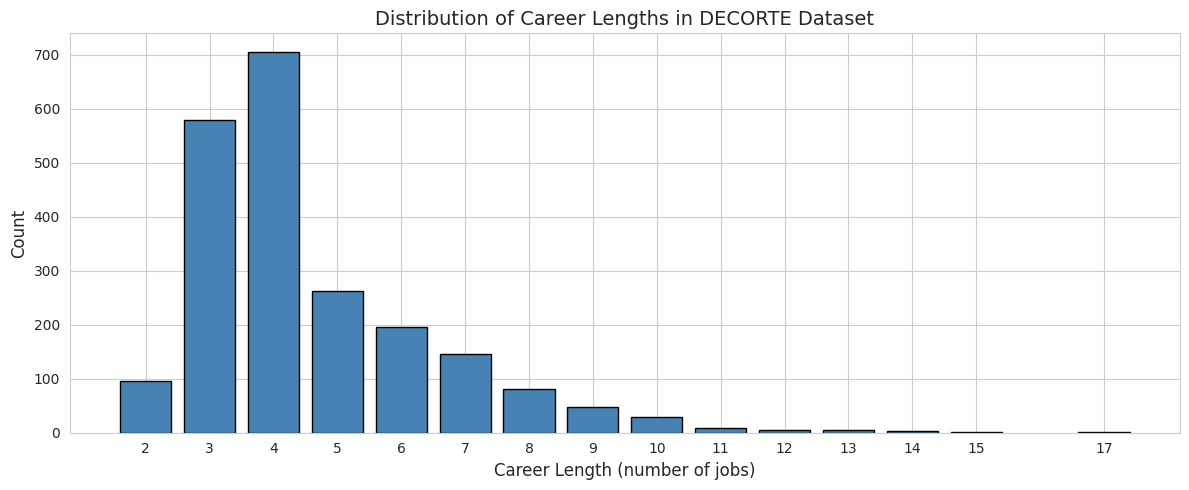

In [10]:
career_length_dist = Counter(all_career_lengths)

print("Career Length Distribution:")
for length in sorted(career_length_dist.keys()):
    count = career_length_dist[length]
    pct = count / len(all_career_lengths) * 100
    print(f"  {length} jobs: {count:,} ({pct:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
lengths = sorted(career_length_dist.keys())
counts = [career_length_dist[l] for l in lengths]
ax.bar(lengths, counts, color='steelblue', edgecolor='black')
ax.set_xlabel('Career Length (number of jobs)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Career Lengths in DECORTE Dataset', fontsize=14)
ax.set_xticks(lengths)
plt.tight_layout()
plt.show()


4.1.3 ESCO Taxonomy

Total number of occupations
Total number of skills
Number of essential vs optional skill relations
Average skills per occupation (essential only, optional only, combined)
Number of L1 skill categories
Number of L2 skill categories
Skills with multiple parents (before DAG expansion)

4.1.4 Exploratory Data Analysis
Statistics needed:

Occupation distribution across 10 ISCO major groups (counts per group)
Skills-per-occupation: mean, median, std, min, max
Career length distribution: histogram data or percentiles (25th, 50th, 75th, 90th)
Transition patterns: % of transitions within same ISCO group vs across groups